# Week 2 Data Exploration

Tasks:
- Load minimum 6 months of dataset into pandas
- Explore Distributions of:
	1. ClosePrice (target variable)
	2. LivingArea 
	3. Bedrooms
	4. Bathrooms
	5. LotSize
- . Restrict Analysis to PropertyType = Residential and SingleFamilyResidence (per task doc)

# Task 1: Load dataset into pandas
(I did it programmatically instead of inserting every individual set by hand.)

It would be helpful to put them all together too

In [1]:
import pandas as pd
import numpy as np

# the root directory of project
root = "C:/Users/donutii/Desktop/IDX-Exchange-Internship-Data-Science-61"

# Fetch houses sold in between May 2025 and May 2026
houses_sold_by_month = []

for month in range(0, 12):
    y = "2025" if month < 8 else "2026"
    m =  ""
    if (month + 5 < 10):
        m = f"0{5 + month}"
    elif (month + 5 >= 10 and month + 5 < 13): 
       m = f"{5 + month}" 
    else:
        m = f"0{month - 7}"
    # print(f"../raw_data/CRMLSSold{y}{m}.csv")-Science-61\raw_data\california\CRMLSSold202506.csv
    filename = f"{root}/raw_data/california/CRMLSSold{y}{m}.csv"
    houses_sold_by_month.append(pd.read_csv(filename))

# Concatenate dataframes
# Ignoring indexes because I'm sure there are duplicates somewhere in the data
houses_sold_2026 = pd.concat(houses_sold_by_month, ignore_index=True)

# Setting float display property with Pandas
pd.set_option('display.float_format', lambda x: '{:,.4f}'.format(x))

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/donutii/Desktop/IDX-Exchange-Internship-Data-Science-61/raw_data/california/CRMLSSold202505.csv'

In [ ]:
# Restricting rows to ones that are Residential and single family (as per task instructions)
# Using this tutorial: https://www.geeksforgeeks.org/python/selecting-rows-in-pandas-dataframe-based-on-conditions/
residential = houses_sold_2026[houses_sold_2026['PropertyType'].isin(['Residential'])]
residential_single_family = residential[residential['PropertySubType'].isin(['SingleFamilyResidence'])]

# Task 2: Explore Distributions
For more explanation on EDAs, it might be helpful to look here: https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/ 

We specifically want to explore the distributions of:
- ClosePrice (the target variable)
- LivingArea
- Bedrooms
- Bathrooms
- LotSize


In [ ]:
# Importing matplotlib 
import matplotlib.pyplot as plt

# Functions
def log_transform(data):
    return data.apply(lambda x: np.log(x) if x > 0 else 0)
def show_histogram(data, bins, color, title, xlabel, log = False):
    plt.hist(data, bins=bins, log=log, color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(f'Frequency {'(Log Scale)' if log else ''}')

    plt.show()

def show_boxplot(data, title, orientation, label, showfliers=True):
    plt.boxplot(data, orientation=orientation, showfliers=showfliers)
    plt.title(title)
    if(orientation == 'vertical'):
        plt.ylabel(label)
    else:
        plt.xlabel(label)

    plt.show()


## Exploring Distributions
I will be using a histogram and box plot to visualize distribution and outliers for the most part, unless the data calls for a different diagram

Before Log Transformation:
count       129,973.0000
mean      1,347,879.6943
std       8,434,714.9793
min               0.0000
25%         625,000.0000
50%         889,000.0000
75%       1,410,000.0000
max     989,500,000.0000
Name: ClosePrice, dtype: float64
After Log Transformation:
count   129,973.0000
mean         13.7770
std           0.6773
min           0.0000
25%          13.3455
50%          13.6979
75%          14.1591
max          20.7127
Name: ClosePrice, dtype: float64


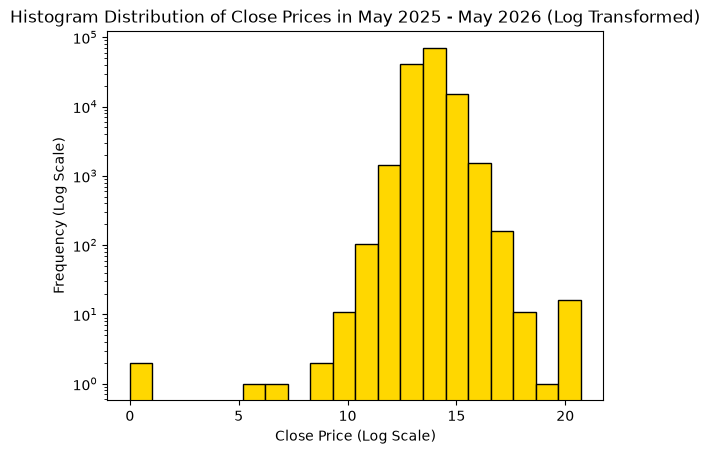

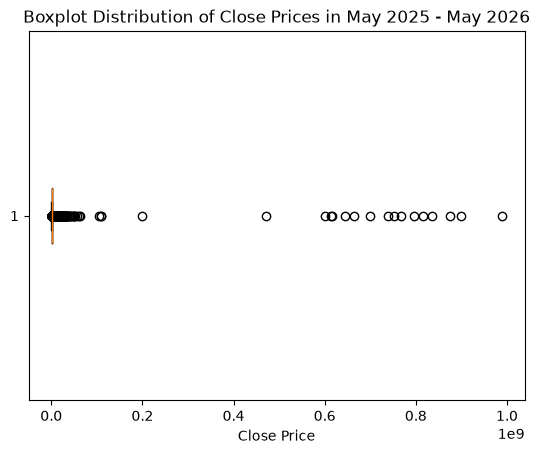

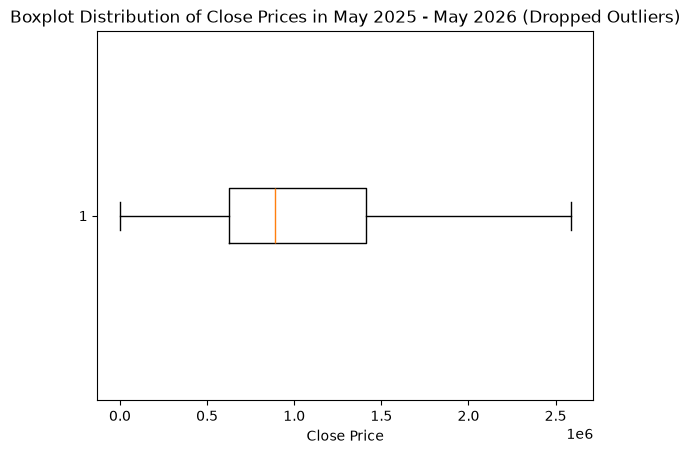

In [ ]:
# Distributions of ClosePrice

# Checking and transforming data
print("Before Log Transformation:")
close_price = residential_single_family['ClosePrice'].dropna()
print(residential_single_family['ClosePrice'].describe())
transformed_price = log_transform(close_price)
print("After Log Transformation:")
print(transformed_price.describe())

# Histogram
show_histogram(transformed_price, bins=20, log=True, color='gold', title='Histogram Distribution of Close Prices in May 2025 - May 2026 (Log Transformed)', xlabel='Close Price (Log Scale)')

# Box plot
# Many outliers exists in the data so I'm showing boxplots with outliers and without
show_boxplot(close_price, title='Boxplot Distribution of Close Prices in May 2025 - May 2026', orientation='horizontal', label='Close Price')
show_boxplot(close_price, title='Boxplot Distribution of Close Prices in May 2025 - May 2026 (Dropped Outliers)', orientation='horizontal', label='Close Price', showfliers=False)


Before Log Transformation:
count   129,902.0000
mean      2,046.3042
std       1,044.5986
min           0.0000
25%       1,385.0000
50%       1,817.0000
75%       2,438.0000
max      56,500.0000
Name: LivingArea, dtype: float64
After Log Transformation:
count   129,902.0000
mean          7.5236
std           0.4584
min           0.0000
25%           7.2335
50%           7.5049
75%           7.7989
max          10.9420
Name: LivingArea, dtype: float64


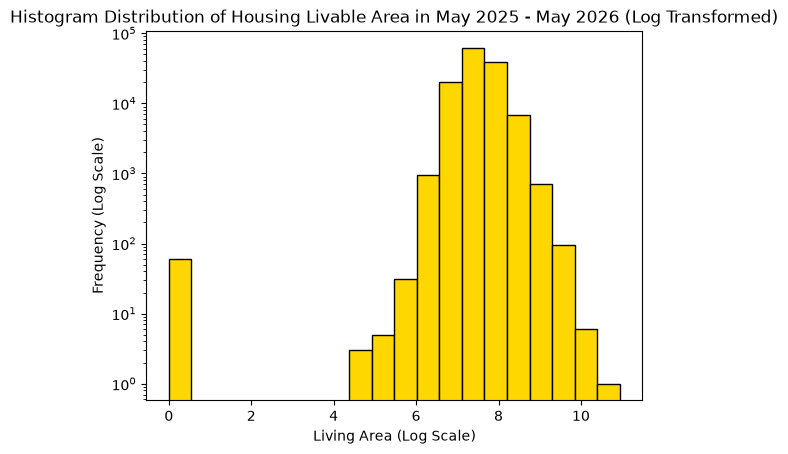

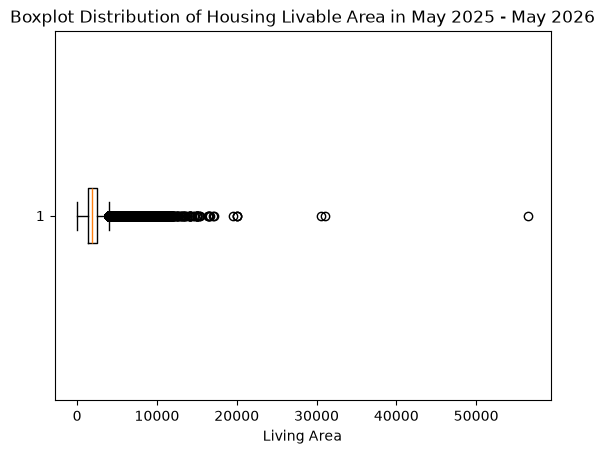

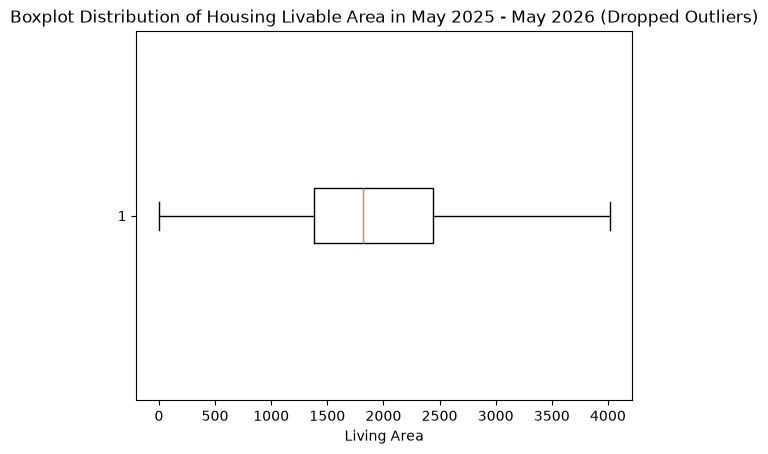

In [ ]:
# Distribution of LivingArea
print("Before Log Transformation:")
living_area = residential_single_family['LivingArea'].dropna()
print(living_area.describe())
transformed_living_area = log_transform(living_area)
print("After Log Transformation:")
print(transformed_living_area.describe())

# Histogram
show_histogram(transformed_living_area, bins=20, log=True, color='gold', title='Histogram Distribution of Housing Livable Area in May 2025 - May 2026 (Log Transformed)', xlabel='Living Area (Log Scale)')

# Box plot
# Many outliers exists in the data so I'm showing boxplots with outliers and without
show_boxplot(residential_single_family['LivingArea'].dropna(), title='Boxplot Distribution of Housing Livable Area in May 2025 - May 2026', orientation='horizontal', label='Living Area')
show_boxplot(residential_single_family['LivingArea'].dropna(), title='Boxplot Distribution of Housing Livable Area in May 2025 - May 2026 (Dropped Outliers)', orientation='horizontal', label='Living Area', showfliers = False)

count   129,973.0000
mean          3.4905
std           0.9643
min           0.0000
25%           3.0000
50%           3.0000
75%           4.0000
max          22.0000
Name: BedroomsTotal, dtype: float64


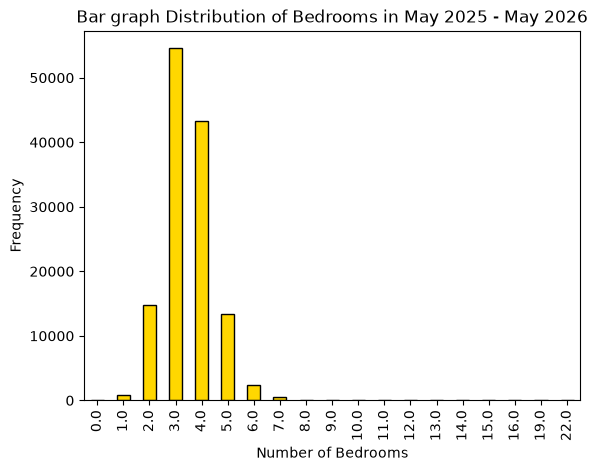

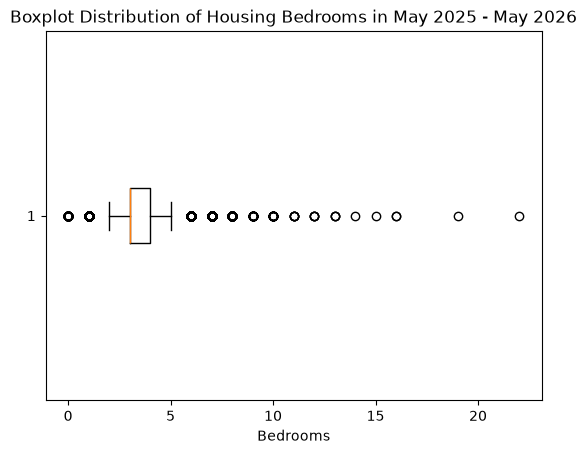

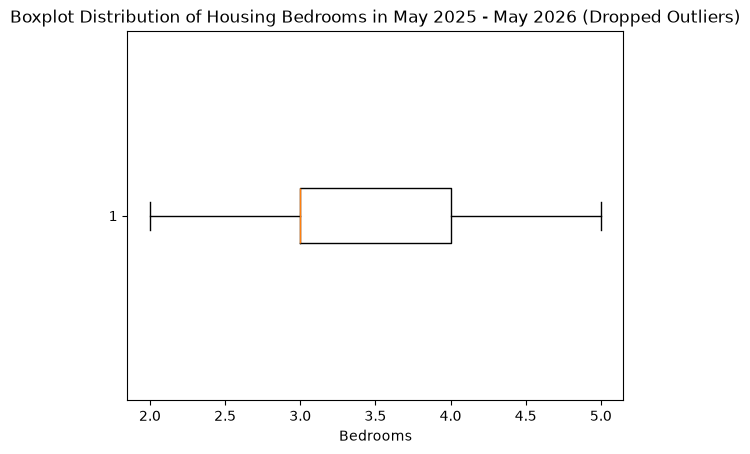

In [ ]:
# Distribution of Bedrooms
bedrooms = residential_single_family['BedroomsTotal'].dropna()
bedroom_range = bedrooms.value_counts().sort_index()
print(residential_single_family['BedroomsTotal'].describe())
# Bar graph, using df plot function for simplicity
bedroom_range.plot(kind='bar', color='gold', edgecolor='black', title='Bar graph Distribution of Bedrooms in May 2025 - May 2026', xlabel='Number of Bedrooms', ylabel='Frequency')
plt.show()

# Box plot
# Many outliers exists in the data so I'm showing boxplots with outliers and without
show_boxplot(bedrooms, title='Boxplot Distribution of Housing Bedrooms in May 2025 - May 2026', orientation='horizontal', label='Bedrooms')
show_boxplot(bedrooms, title='Boxplot Distribution of Housing Bedrooms in May 2025 - May 2026 (Dropped Outliers)', orientation='horizontal', label='Bedrooms', showfliers = False)

count   129,960.0000
mean          2.6294
std           1.1314
min           0.0000
25%           2.0000
50%           2.0000
75%           3.0000
max          35.0000
Name: BathroomsTotalInteger, dtype: float64


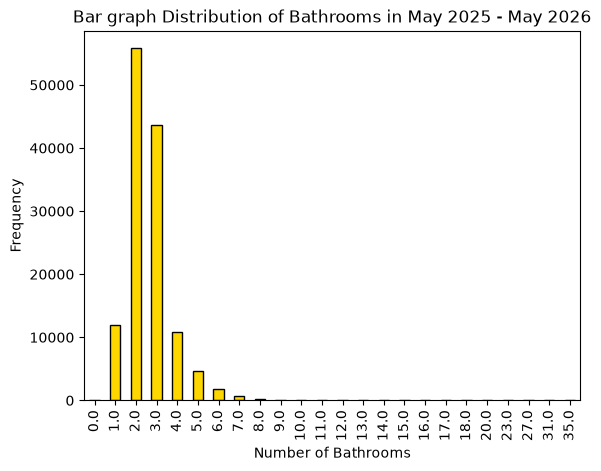

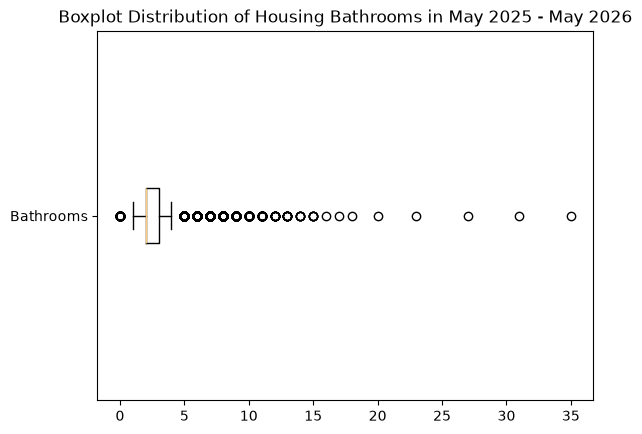

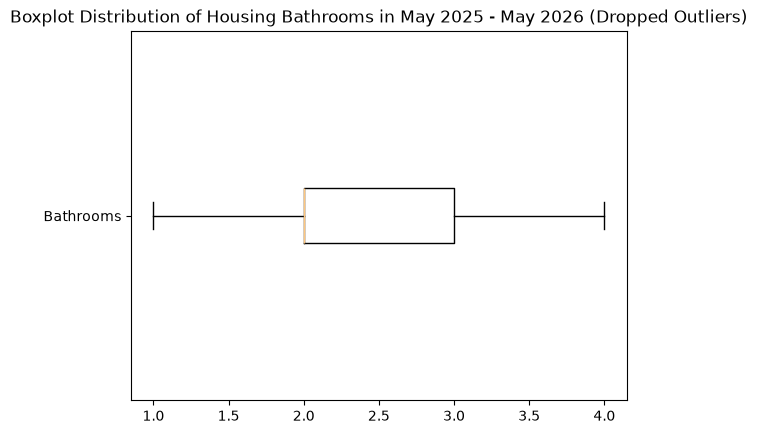

In [ ]:
# Distribution of Bathrooms
bathrooms = residential_single_family['BathroomsTotalInteger'].dropna()
bathroom_range = bathrooms.value_counts(sort=False).sort_index()
print(bathrooms.describe())
# Bar graph, using df plot function for simplicity
bathroom_range.plot(kind='bar', color='gold', edgecolor='black', title='Bar graph Distribution of Bathrooms in May 2025 - May 2026', xlabel='Number of Bathrooms', ylabel='Frequency')
plt.show()

# Box plot
# Many outliers exists in the data so I'm showing boxplots with outliers and without
bathrooms.plot(kind='box', vert=False, title='Boxplot Distribution of Housing Bathrooms in May 2025 - May 2026', colormap='copper', label='Bathrooms')
plt.show()
bathrooms.plot(kind='box', vert=False, title='Boxplot Distribution of Housing Bathrooms in May 2025 - May 2026 (Dropped Outliers)', colormap='copper', label='Bathrooms', showfliers=False)
plt.show()
#show_boxplot(residential_single_family['BathroomsTotalInteger'], title='Boxplot Distribution of Housing Bathrooms in May 2025 - May 2026 (Dropped Outliers)', orientation='horizontal', label='Bathrooms', showfliers = False)

count         127,744.0000
mean          396,864.2596
std        18,166,485.2709
min                 0.0000
25%             5,663.0000
50%             7,292.0000
75%            10,454.0000
max     1,938,942,720.0000
Name: LotSizeSquareFeet, dtype: float64
count   127,744.0000
mean          9.0672
std           1.0583
min          -3.5066
25%           8.6417
50%           8.8945
75%           9.2547
max          21.3854
Name: LotSizeSquareFeet, dtype: float64


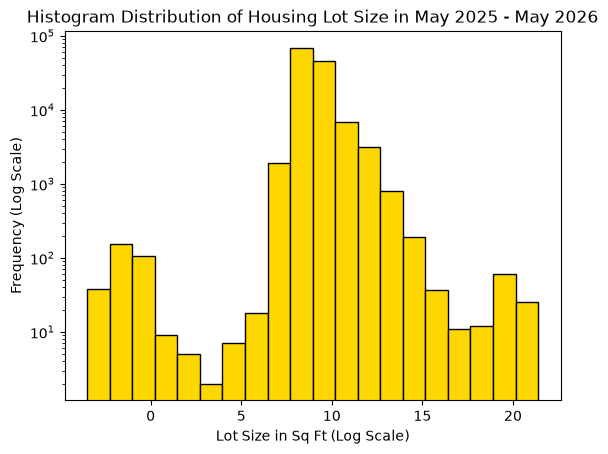

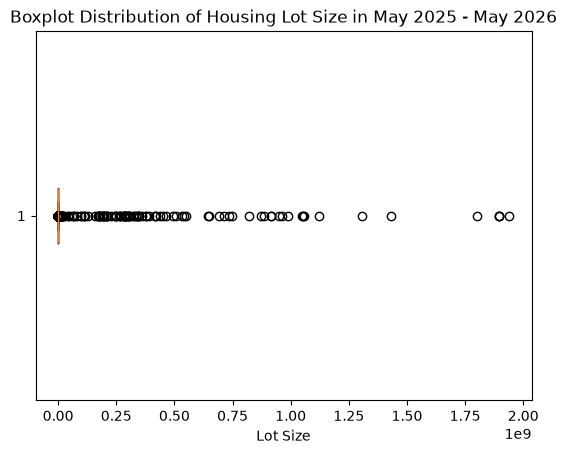

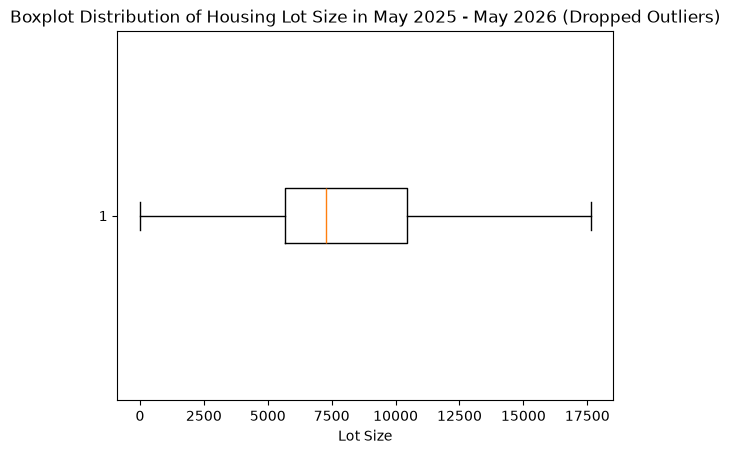

In [ ]:
# Distribution of LotSize
square_footage = residential_single_family['LotSizeSquareFeet'].dropna()
print(residential_single_family['LotSizeSquareFeet'].dropna().describe())
transformed_square_footage = log_transform(residential_single_family['LotSizeSquareFeet'].dropna())
print(transformed_square_footage.describe())
# Histogram
show_histogram(transformed_square_footage, bins=20, log=True, color='gold', title='Histogram Distribution of Housing Lot Size in May 2025 - May 2026', xlabel='Lot Size in Sq Ft (Log Scale)')

# Box plot
# Many outliers exists in the data so I'm showing boxplots with outliers and without
show_boxplot(square_footage, title='Boxplot Distribution of Housing Lot Size in May 2025 - May 2026', orientation='horizontal', label='Lot Size')
show_boxplot(square_footage, title='Boxplot Distribution of Housing Lot Size in May 2025 - May 2026 (Dropped Outliers)', orientation='horizontal', label='Lot Size', showfliers = False)

## Conclusions
1. Close Price: Had the largest range and the most outliers, though once log transformed and scaled, data seems to be skewed to the right.
2. Living Area: Distribution was similar to Close Price once log transformed and skaled, though the range was smaller.
3. Bedrooms: Lots of outliers, though most seemed to fall in between 3-4
4. Bathrooms: Similar to bedrooms, though most fell in between 2-3
5. Housing Size: Had a nonuniform distribution according to the histogram, though frequency seems to be concentrated in the middle and ends.

# Exploring Bivariate Relationships
Basically, each variable's relationship with Close Price (target variable)

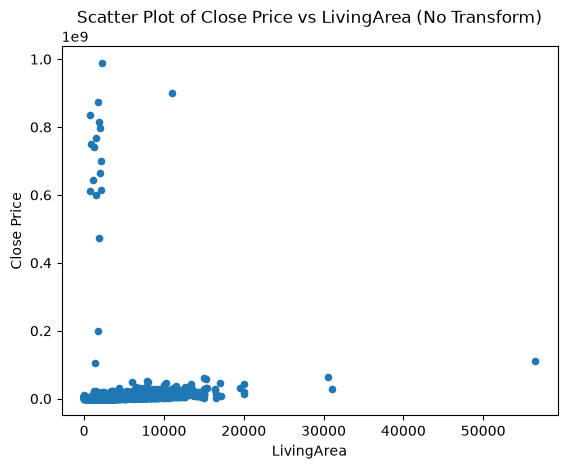

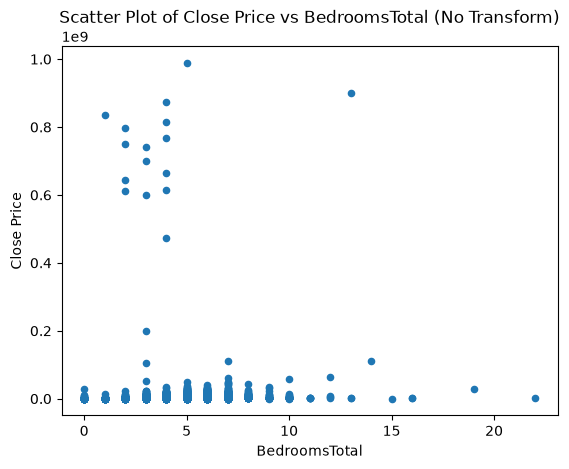

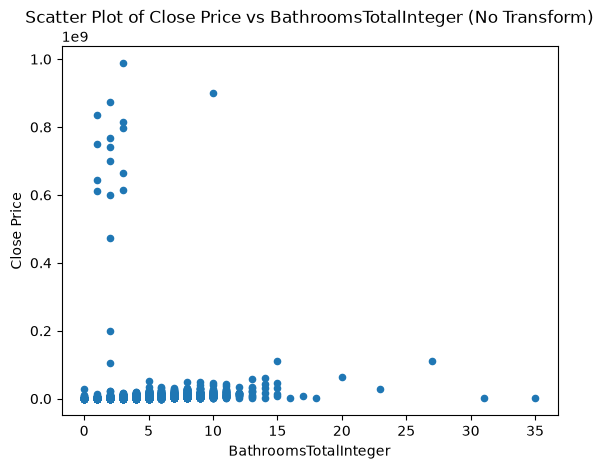

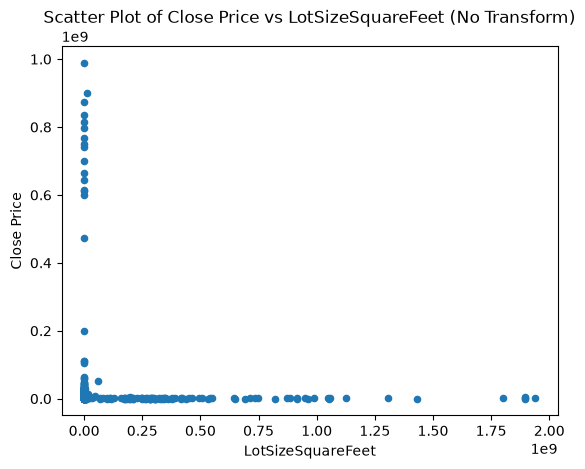

In [ ]:
columns = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
for col in columns:
    residential_single_family.plot.scatter(x=col, y='ClosePrice', title=f'Scatter Plot of Close Price vs {col} (No Transform)', xlabel=col, ylabel='Close Price')


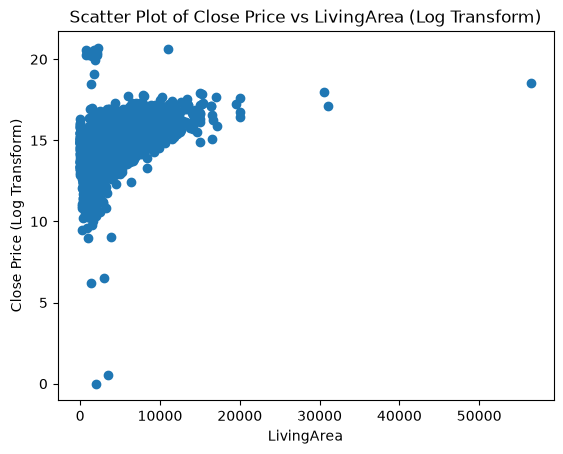

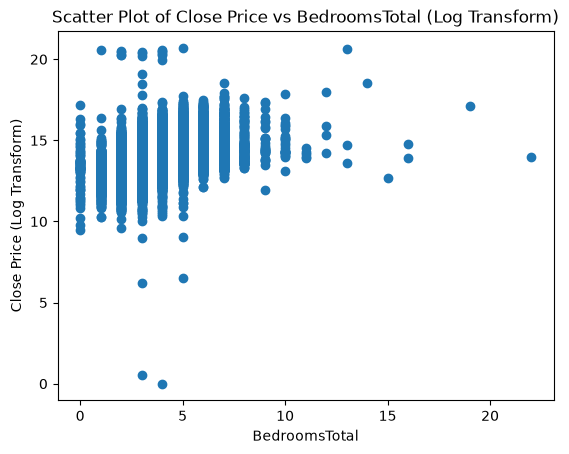

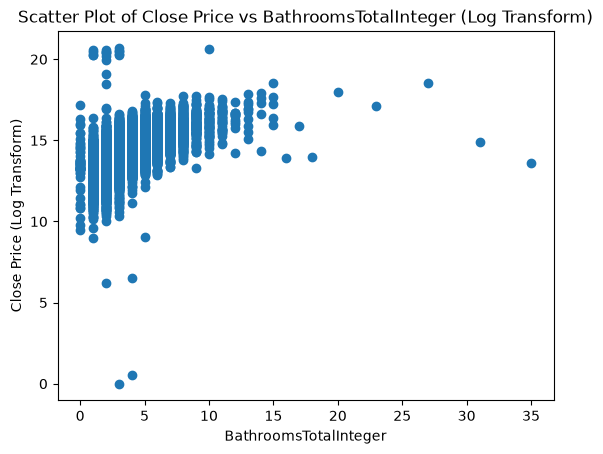

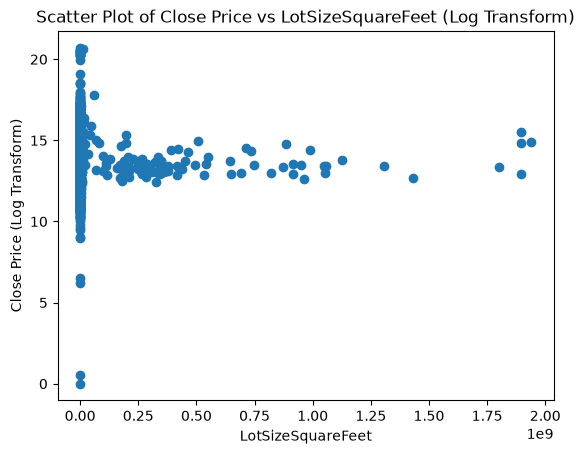

In [ ]:
# Now with transformed data
transformed_col = log_transform(residential_single_family['ClosePrice'].dropna())
columns = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
for col in columns:
    plt.scatter(x=residential_single_family[col], y=transformed_col)
    plt.title(f'Scatter Plot of Close Price vs {col} (Log Transform)')
    plt.xlabel(col)
    plt.ylabel('Close Price (Log Transform)')
    plt.show()


# Conclusion
1. There seems to be interesting behaviour when any of the values are zero, needs discussion. Could possibly be an error.
2. For variables (excluding lot size square feet), most vaguely resemble a messy logarithmic relationship 
3. Lot size square feet seems to have a linear relationship, though the close price stays within a certain range irrespective of Close Price 